# 06 — Visualization (fixed for model v1.4)
Generates presentation-ready charts from model predictions.
Output: `outputs/` PNG files

**Fix vs original:** v1.4 predictions use a plain `state` text column, not `state_IOWA` one-hot columns.
This notebook filters by `state` name directly and uses `forecast_date` for the cone of uncertainty.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── LOAD DATA ─────────────────────────────────────────────────────────────────
yield_df = pd.read_csv("../data/processed/quickstats_yield.csv")
preds    = pd.read_csv("../outputs/predictions.05_model1.4.csv")

# Normalise capitalisation — yield_df may be uppercase, preds are title-case
yield_df['state'] = yield_df['state'].str.title()
preds['state']    = preds['state'].str.title()

STATES         = ['Iowa', 'Colorado', 'Wisconsin', 'Missouri', 'Nebraska']
# Ordered for the cone chart — dates become x-axis points
FORECAST_ORDER = ['aug1', 'sep1', 'oct1', 'final']
DATE_LABELS    = {'aug1': 'Aug 1', 'sep1': 'Sep 1', 'oct1': 'Oct 1', 'final': 'Nov 1'}

print("Historical yield loaded:", yield_df.shape)
print("Predictions loaded:", preds.shape)
print("Forecast dates present:", preds['forecast_date'].unique())
print("States in predictions:", preds['state'].unique())

Historical yield loaded: (100, 3)
Predictions loaded: (20, 9)
Forecast dates present: ['aug1' 'sep1' 'oct1' 'final']
States in predictions: ['Colorado' 'Iowa' 'Missouri' 'Nebraska' 'Wisconsin']


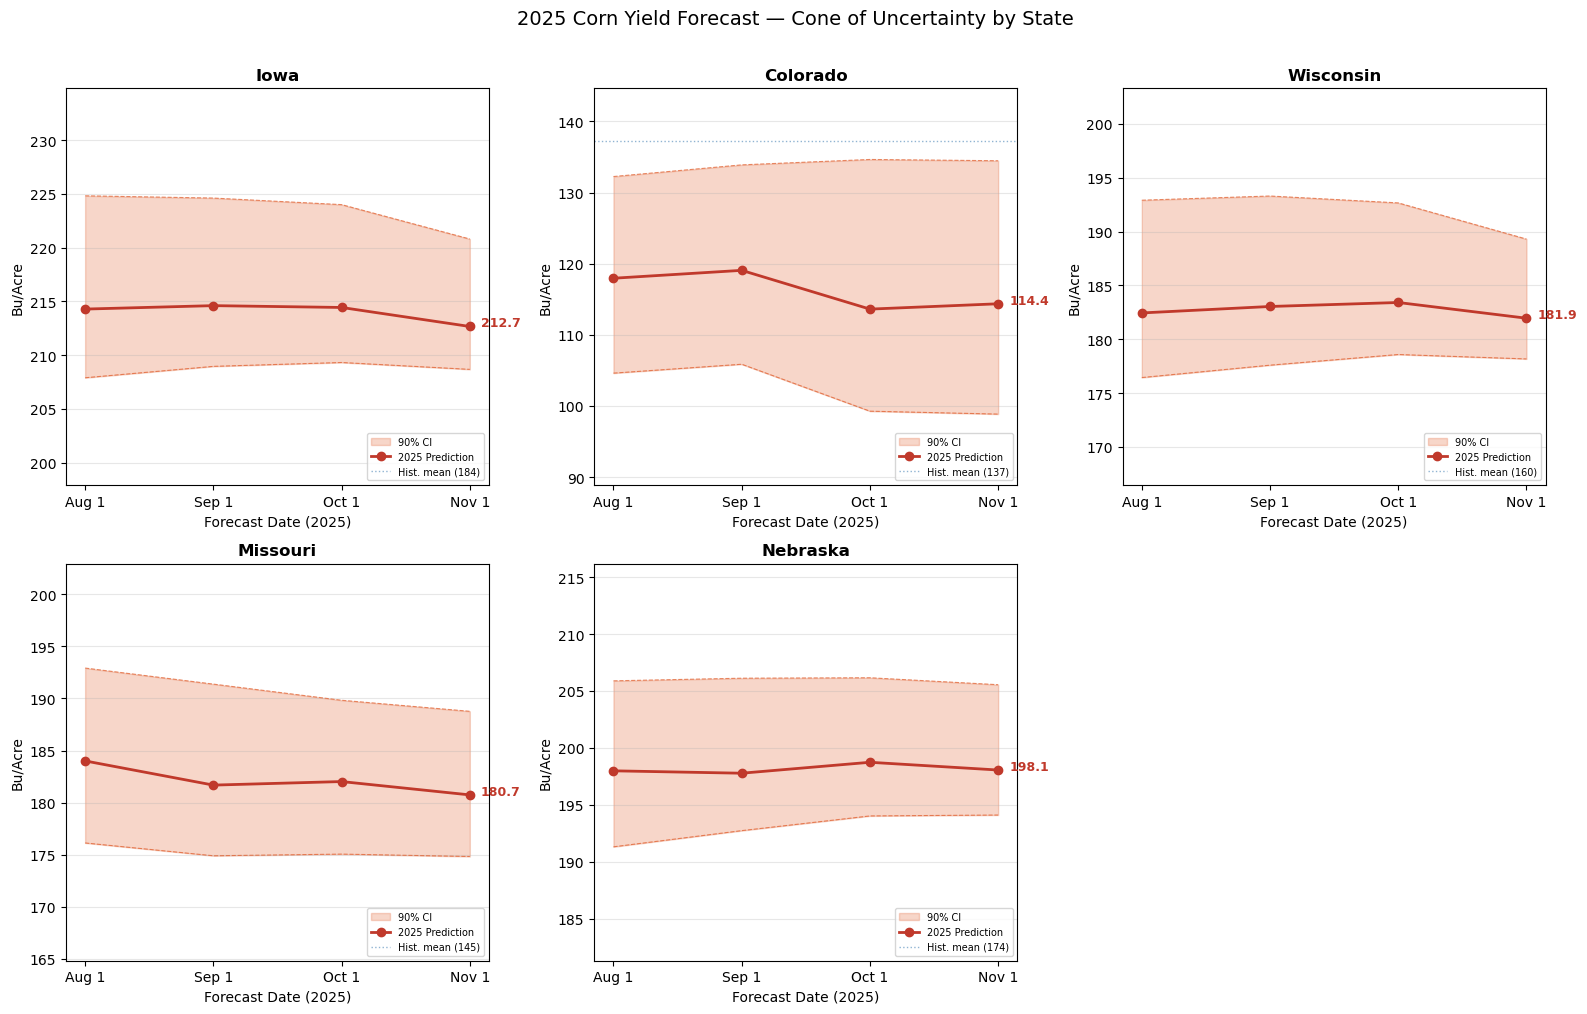

Saved: outputs/cone_of_uncertainty.png


In [2]:
# ── CHART 1: CONE OF UNCERTAINTY — one panel per state ───────────────────────
# Shows predicted yield + shaded 90% CI narrowing from Aug → Nov.
# This is the deliverable the judges asked for.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

x_pos = np.arange(len(FORECAST_ORDER))   # 0,1,2,3

for i, state in enumerate(STATES):
    ax = axes[i]

    # Historical line
    hist = yield_df[yield_df['state'] == state].sort_values('year')
    if len(hist) == 0:
        ax.set_title(f"{state} — no history")
        continue

    # Pull 2025 predictions for this state, ordered by FORECAST_ORDER
    sp = (
        preds[preds['state'] == state]
        .set_index('forecast_date')
        .reindex(FORECAST_ORDER)
    )

    pred_vals = sp['predicted_yield'].values
    ci_lo     = sp['ci_lower'].values
    ci_hi     = sp['ci_upper'].values

    # ── Cone of uncertainty ──
    # Fill between lower and upper CI — band should narrow toward final
    ax.fill_between(x_pos, ci_lo, ci_hi,
                    alpha=0.25, color='#E05C2A', label='90% CI')

    # CI boundary lines
    ax.plot(x_pos, ci_lo, '--', color='#E05C2A', linewidth=0.8, alpha=0.7)
    ax.plot(x_pos, ci_hi, '--', color='#E05C2A', linewidth=0.8, alpha=0.7)

    # Predicted yield line
    ax.plot(x_pos, pred_vals, 'o-',
            color='#C0392B', linewidth=2, markersize=6,
            label='2025 Prediction', zorder=5)

    # Annotate final prediction value
    if not np.isnan(pred_vals[-1]):
        ax.annotate(
            f"{pred_vals[-1]:.1f}",
            xy=(x_pos[-1], pred_vals[-1]),
            xytext=(8, 0), textcoords='offset points',
            fontsize=9, color='#C0392B', fontweight='bold'
        )

    # Historical mean as reference line
    hist_mean = hist['yield_bu_acre'].mean()
    ax.axhline(hist_mean, color='steelblue', linestyle=':', linewidth=1,
               alpha=0.6, label=f'Hist. mean ({hist_mean:.0f})')

    ax.set_title(state, fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([DATE_LABELS[d] for d in FORECAST_ORDER])
    ax.set_ylabel('Bu/Acre')
    ax.set_xlabel('Forecast Date (2025)')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

    # Y-axis: anchor to realistic range around predictions
    ymin = np.nanmin(ci_lo) - 10
    ymax = np.nanmax(ci_hi) + 10
    ax.set_ylim(ymin, ymax)

axes[-1].set_visible(False)
plt.suptitle('2025 Corn Yield Forecast — Cone of Uncertainty by State', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/cone_of_uncertainty.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/cone_of_uncertainty.png")

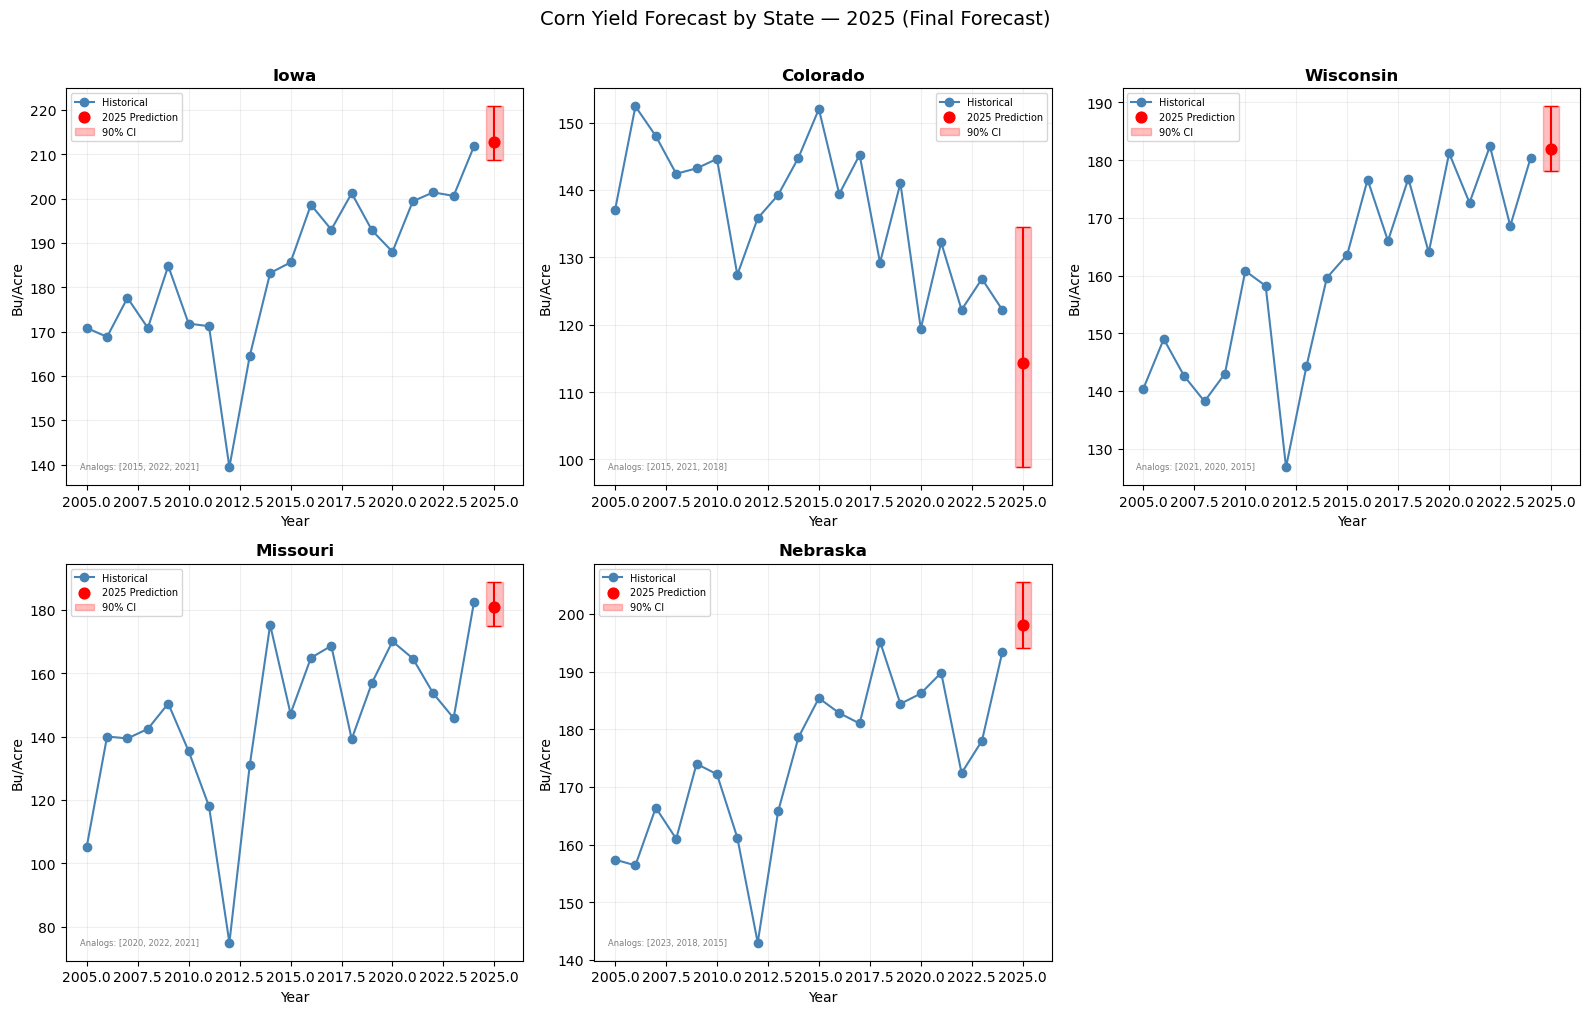

Saved: outputs/yield_forecast_by_state.png


In [3]:
# ── CHART 2: Historical trends + 2025 point prediction ───────────────────────
# Uses the 'final' forecast as the 2025 prediction point.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, state in enumerate(STATES):
    ax = axes[i]

    hist = yield_df[yield_df['state'] == state].sort_values('year')
    ax.plot(hist['year'], hist['yield_bu_acre'],
            'o-', label='Historical', color='steelblue', linewidth=1.5)

    # Use 'final' forecast row as the 2025 prediction
    final_pred = preds[
        (preds['state'] == state) &
        (preds['forecast_date'] == 'final')
    ]

    if len(final_pred) > 0:
        row = final_pred.iloc[0]
        ax.scatter(2025, row['predicted_yield'],
                   color='red', zorder=5, s=60, label='2025 Prediction')
        ax.fill_between(
            [2024.6, 2025.4],
            row['ci_lower'], row['ci_upper'],
            alpha=0.25, color='red', label='90% CI'
        )
        # Error bar for CI
        ax.errorbar(
            2025, row['predicted_yield'],
            yerr=[[row['predicted_yield'] - row['ci_lower']],
                  [row['ci_upper'] - row['predicted_yield']]],
            fmt='none', color='red', capsize=5, linewidth=1.5
        )
        # Annotate analog years
        ax.annotate(
            f"Analogs: {row['analog_years']}",
            xy=(0.03, 0.04), xycoords='axes fraction',
            fontsize=6, color='gray'
        )

    ax.set_title(state, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Bu/Acre')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

axes[-1].set_visible(False)
plt.suptitle('Corn Yield Forecast by State — 2025 (Final Forecast)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/yield_forecast_by_state.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/yield_forecast_by_state.png")

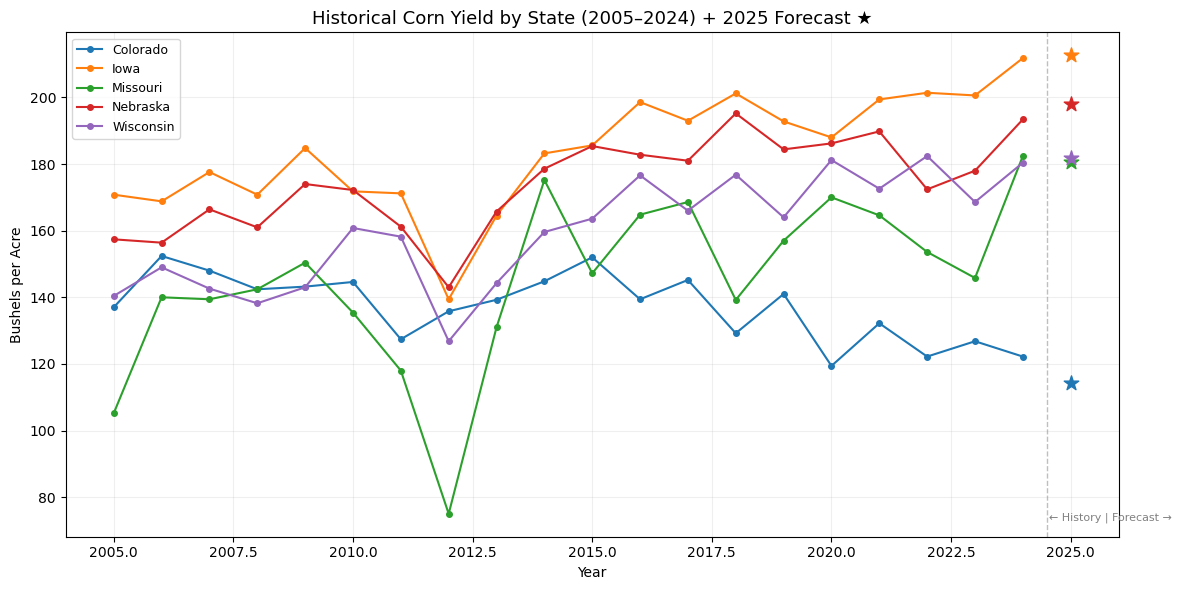

Saved: outputs/historical_yield_trends.png


In [4]:
# ── CHART 3: All states historical trends on one plot ────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.tab10.colors
for j, (state, group) in enumerate(yield_df.groupby('state')):
    group = group.sort_values('year')
    ax.plot(group['year'], group['yield_bu_acre'],
            marker='o', markersize=4,
            color=colors[j % len(colors)], label=state)

    # Add 2025 final prediction for each state
    fp = preds[(preds['state'] == state.title()) & (preds['forecast_date'] == 'final')]
    if len(fp) > 0:
        ax.scatter(2025, fp['predicted_yield'].values[0],
                   color=colors[j % len(colors)], marker='*', s=120, zorder=5)

ax.axvline(2024.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(2024.55, ax.get_ylim()[0] + 5, '← History | Forecast →',
        fontsize=8, color='gray')

ax.set_title("Historical Corn Yield by State (2005–2024) + 2025 Forecast ★", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Bushels per Acre")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../outputs/historical_yield_trends.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/historical_yield_trends.png")

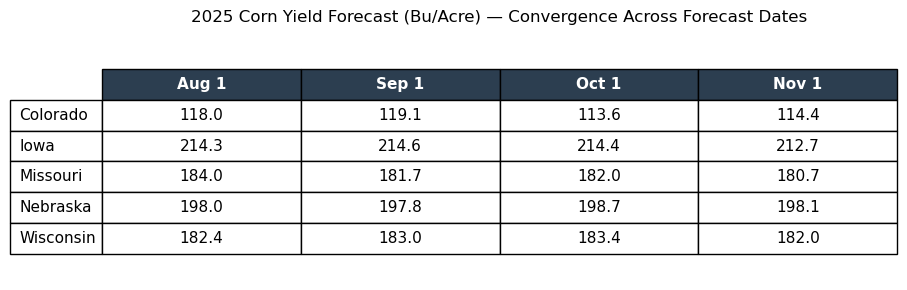

Saved: outputs/forecast_convergence_table.png


In [5]:
# ── CHART 4: Forecast convergence table ──────────────────────────────────────
# Shows how the prediction changes across forecast dates — good slide visual

pivot = (
    preds[preds['forecast_date'].isin(FORECAST_ORDER)]
    .pivot_table(index='state', columns='forecast_date', values='predicted_yield')
    .reindex(columns=FORECAST_ORDER)
)
pivot.columns = [DATE_LABELS[d] for d in FORECAST_ORDER]

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

tbl = ax.table(
    cellText=pivot.round(1).values,
    rowLabels=pivot.index,
    colLabels=pivot.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.8)

# Colour header row
for j in range(len(pivot.columns)):
    tbl[(0, j)].set_facecolor('#2C3E50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

plt.title('2025 Corn Yield Forecast (Bu/Acre) — Convergence Across Forecast Dates',
          fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../outputs/forecast_convergence_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/forecast_convergence_table.png")